In [ ]:
from datetime import datetime
from getpass import getpass

rdm_url = 'http://localhost:5001/'
idp_name_2 = 'FakeCAS'
idp_username_2 = None
idp_password_2 = None
weko_index_name = 'GRDM-Collaboration-Test-VR-1'
default_result_path = None
close_on_fail = False
transition_timeout = 30000
browser_type = 'chromium'
ignore_https_errors = False
project_name = None
project_url = None
default_storage_label = 'NII Storage'

In [ ]:
if idp_username_2 is None:
    prompt = f"Username for {idp_name_2 or 'user account'}: "
    idp_username_2 = input(prompt)
if idp_password_2 is None:
    prompt = f"Password for {idp_username_2}: "
    idp_password_2 = getpass(prompt)

if project_name is None:
    project_name = datetime.now().strftime('TEST-WEKO-%Y%m%d%H%M')

# メタデータのWEKOへの送信

- サブシステム名: アドオン
- ページ/アドオン: Metadata, WEKO
- 機能分類: メタデータの送信
- シナリオ名: メタデータのWEKOへの送信
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM一般ユーザー, WEKO教員以上)
- 事前条件: 「プロジェクトに対するWEKOアドオンの登録」を実施済みであること

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpoxftrs4z'

In [71]:
import importlib
import os

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm
from scripts.metadata_v2025 import ProjectMetadataForm, FileMetadataForm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, ignore_https_errors=ignore_https_errors)

('20251208-194002',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj8ld8q5t')

## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

Start epoch: 1765190402.2453592 seconds


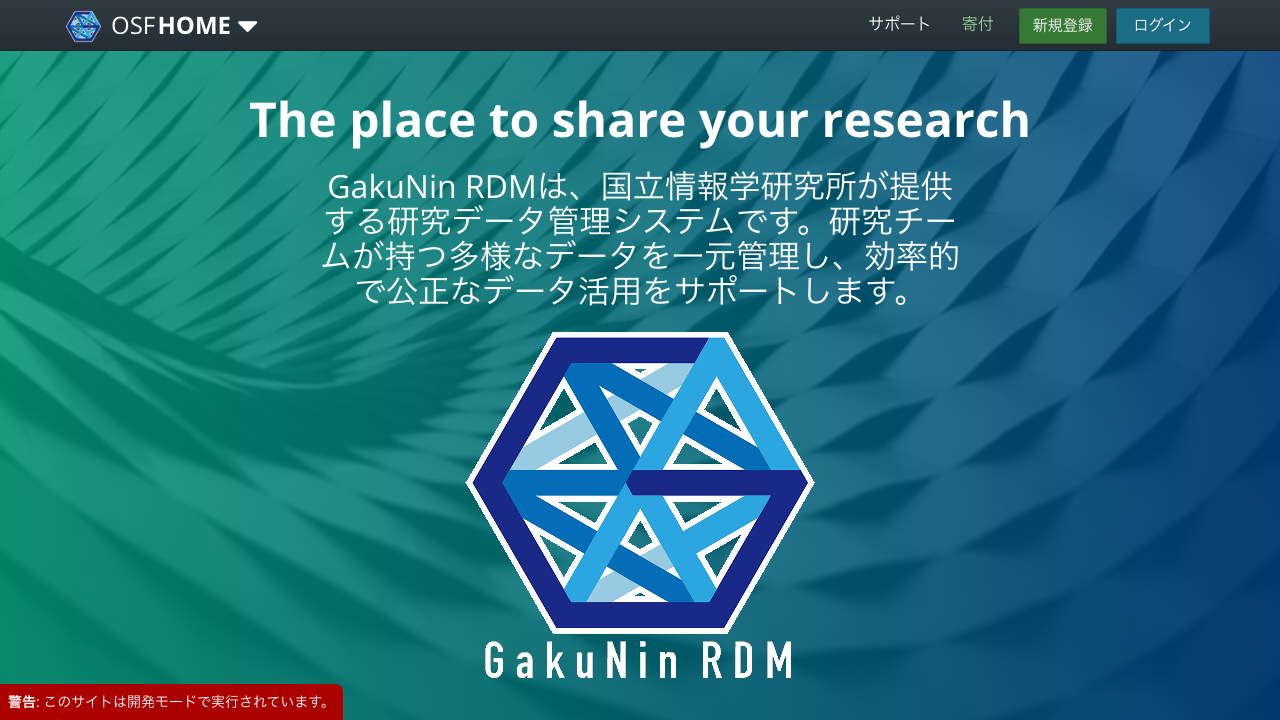

In [72]:
async def _step(page):
    await page.goto(rdm_url)
    consent_button = page.locator('//button[text() = "同意する"]')
    if await consent_button.count():
        await consent_button.click()
    await expect(page.locator('//button[text() = "ログイン"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step, new_page=True)

## IdPを利用し、既存ユーザー1としてログインする

GRDMダッシュボードが表示されること

In [ ]:
async def _step(page):
    await grdm.login(page, idp_name_2, idp_username_2, idp_password_2, transition_timeout=transition_timeout)
    await grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

作成したプロジェクトのプロジェクトダッシュボードが表示されること

Start epoch: 1765190409.358329 seconds


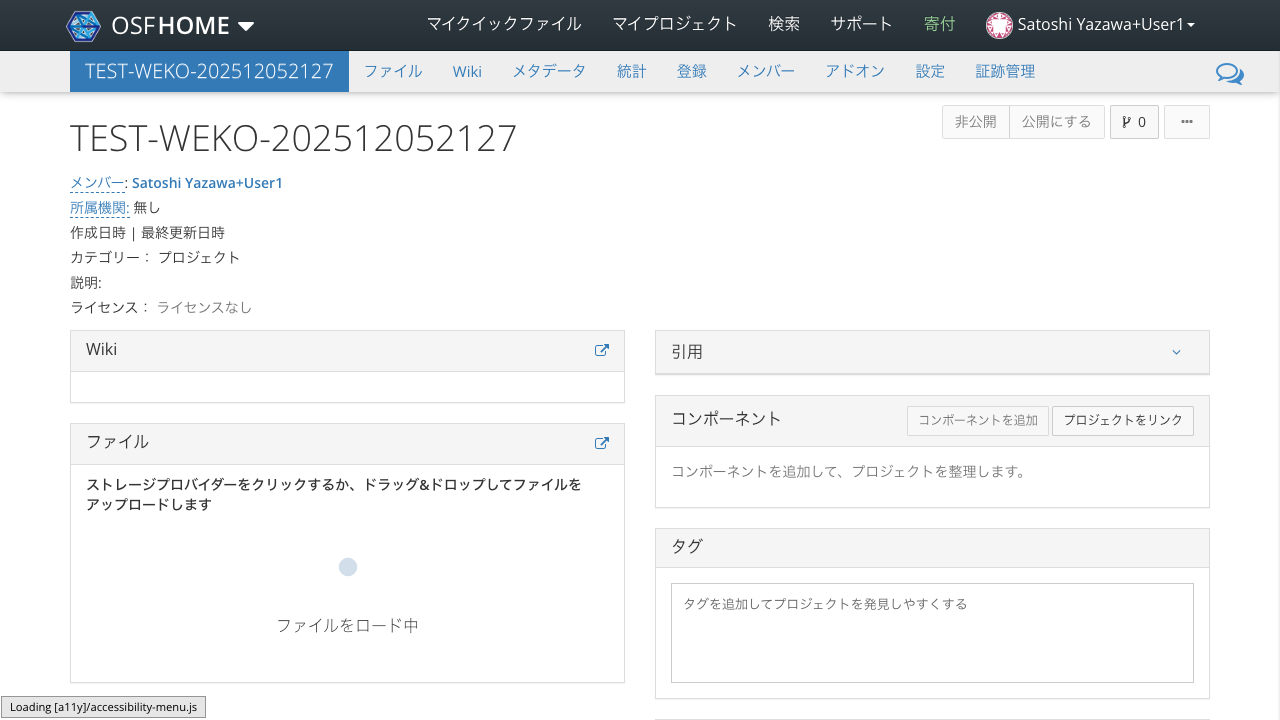

In [74]:
async def _step(page):
    project_link = page.locator(f'//*[@data-test-dashboard-item-title and text() = "{project_name}"]')
    await expect(project_link).to_be_visible(timeout=transition_timeout)
    await project_link.click()
    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    global project_url
    project_url = page.url

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「メタデータ」をクリックする

メタデータの一覧ページが表示されること

Start epoch: 1765190410.7976809 seconds


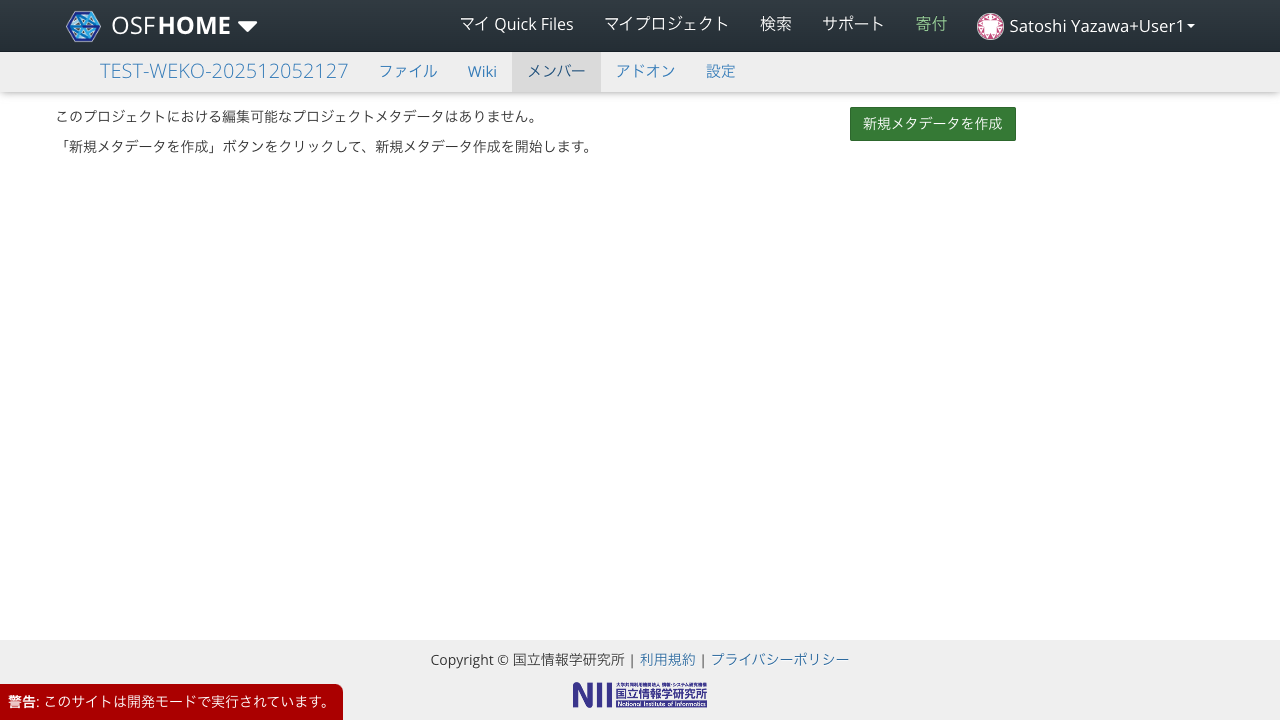

In [75]:
async def _step(page):
    await page.locator('//a[contains(text(), "メタデータ")]').click()
    await expect(page.locator('//button[@data-test-new-metadata-button]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「新規メタデータ」をクリックする

スキーマ選択ダイアログが表示されること

Start epoch: 1765190416.421031 seconds


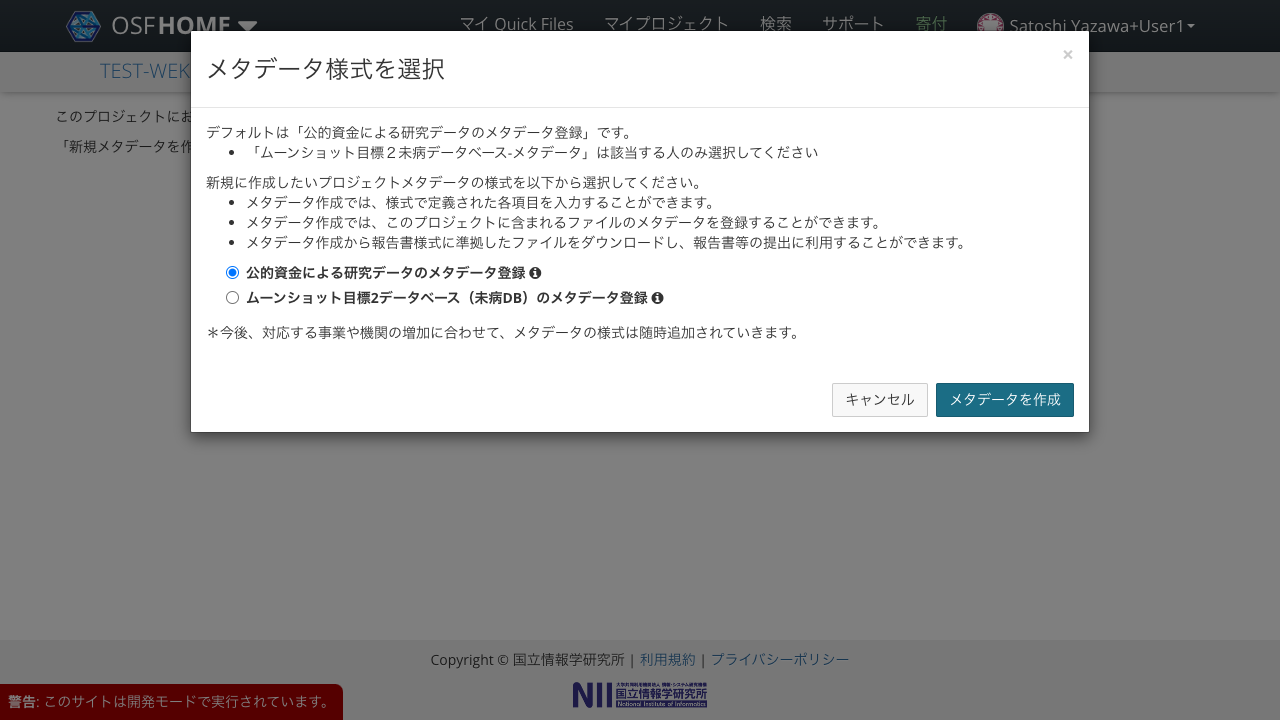

In [76]:
import asyncio

async def _step(page):
    await page.locator('//button[@data-test-new-metadata-button]').click()
    await expect(page.locator('//*[@data-test-new-report-modal-schema="公的資金による研究データのメタデータ登録"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//button[text()="メタデータを作成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「メタデータを作成」をクリックする

メタデータ編集ウィンドウが表示されること

Start epoch: 1765190418.4373739 seconds


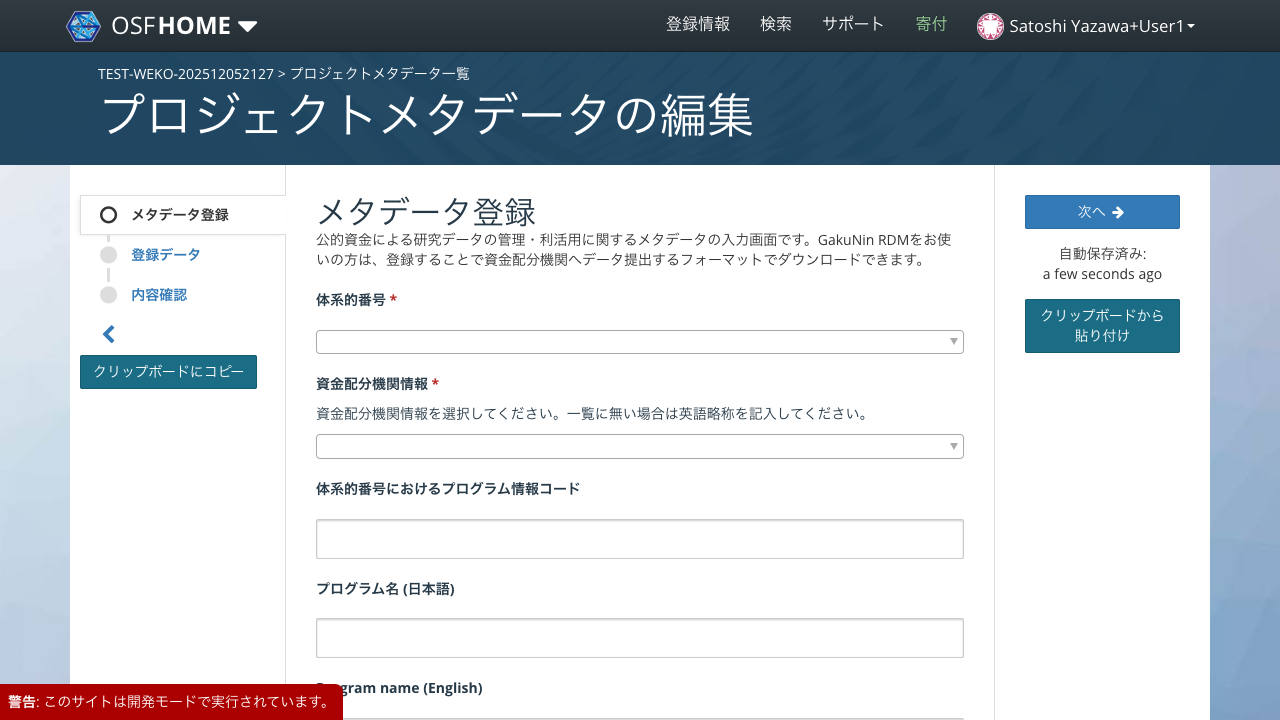

In [77]:
async def _step(page):
    await page.locator('//button[text() = "メタデータを作成"]').click()
    await expect(page.locator('//*[contains(text(), "資金配分機関情報")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 全ての入力欄に正常系の値を入力する

正常系の値は以下の通り:
- 資金配分機関情報: 国立研究開発法人日本医療研究開発機構 | AMED
- 体系的番号におけるプログラム情報コード: abc12
- プログラム名 (日本語): プログラムA
- Program name (English): ProgramA
- 体系的番号: TEST123456
- プロジェクト名 (日本語): プロジェクトA
- Project name (English): ProjectA
- プロジェクトの分野: 社会基盤 | 789

各フィールドに入力した値が表示されること

Start epoch: 1765190423.4515998 seconds


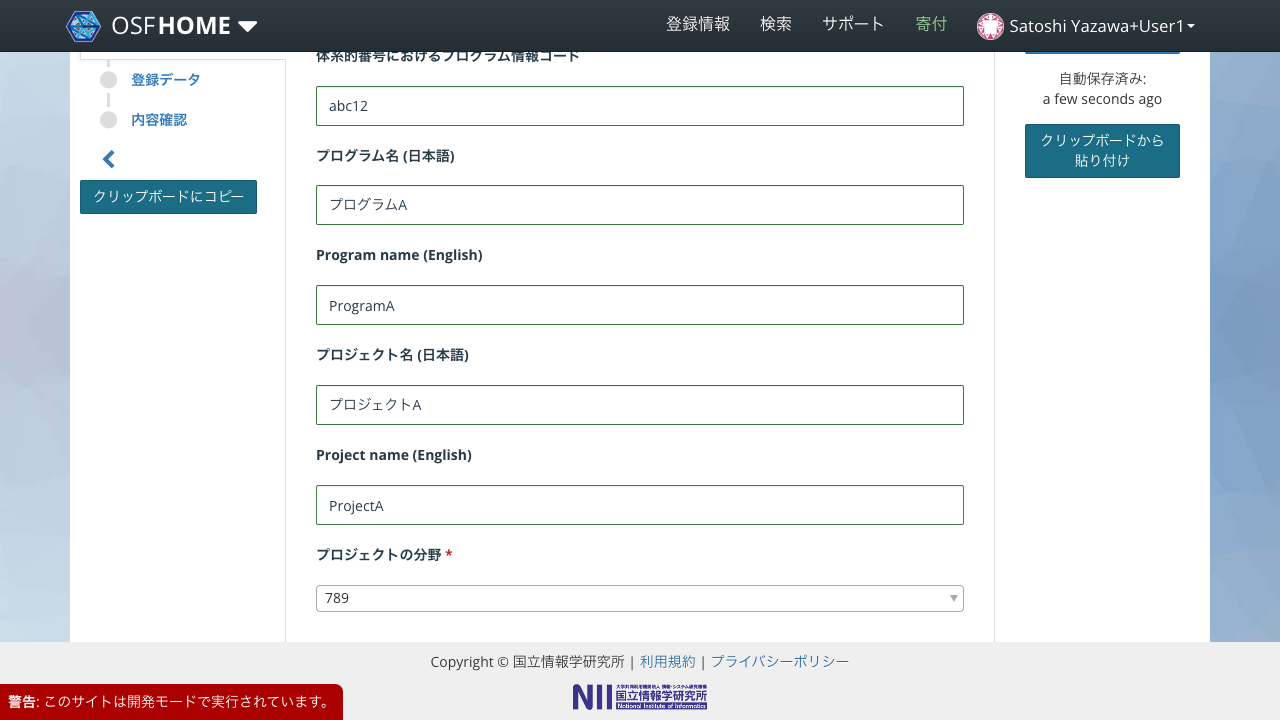

In [78]:
importlib.reload(scripts.metadata_v2025)
from scripts.metadata_v2025 import ProjectMetadataForm, FileMetadataForm

async def _step(page):
    form = ProjectMetadataForm(page)
    
    await form.fill("資金配分機関情報", "国立研究開発法人日本医療研究開発機構 | AMED")
    await form.fill("体系的番号におけるプログラム情報コード", "abc12")
    await form.fill("プログラム名 (日本語)", "プログラムA")
    await form.fill("Program name (English)", "ProgramA")
    await form.fill_power_select_by_search("体系的番号", "TEST123456")
    await form.fill("プロジェクト名 (日本語)", "プロジェクトA")
    await form.fill("Project name (English)", "ProjectA")
    await form.fill("プロジェクトの分野", "社会基盤 | 789")
    
    # Verify values
    assert "AMED" in await form.get("資金配分機関情報")
    assert await form.get("体系的番号におけるプログラム情報コード") == "abc12"
    assert await form.get("プログラム名 (日本語)") == "プログラムA"
    assert await form.get("Program name (English)") == "ProgramA"
    assert "TEST123456" in await form.get("体系的番号")
    assert await form.get("プロジェクト名 (日本語)") == "プロジェクトA"
    assert await form.get("Project name (English)") == "ProjectA"
    assert "789" in await form.get("プロジェクトの分野")

await run_pw(_step)

## 「次へ」をクリックする

左側ペイン「メタデータ登録」が緑色かつチェックマークが表示されること

Start epoch: 1765190423.931566 seconds


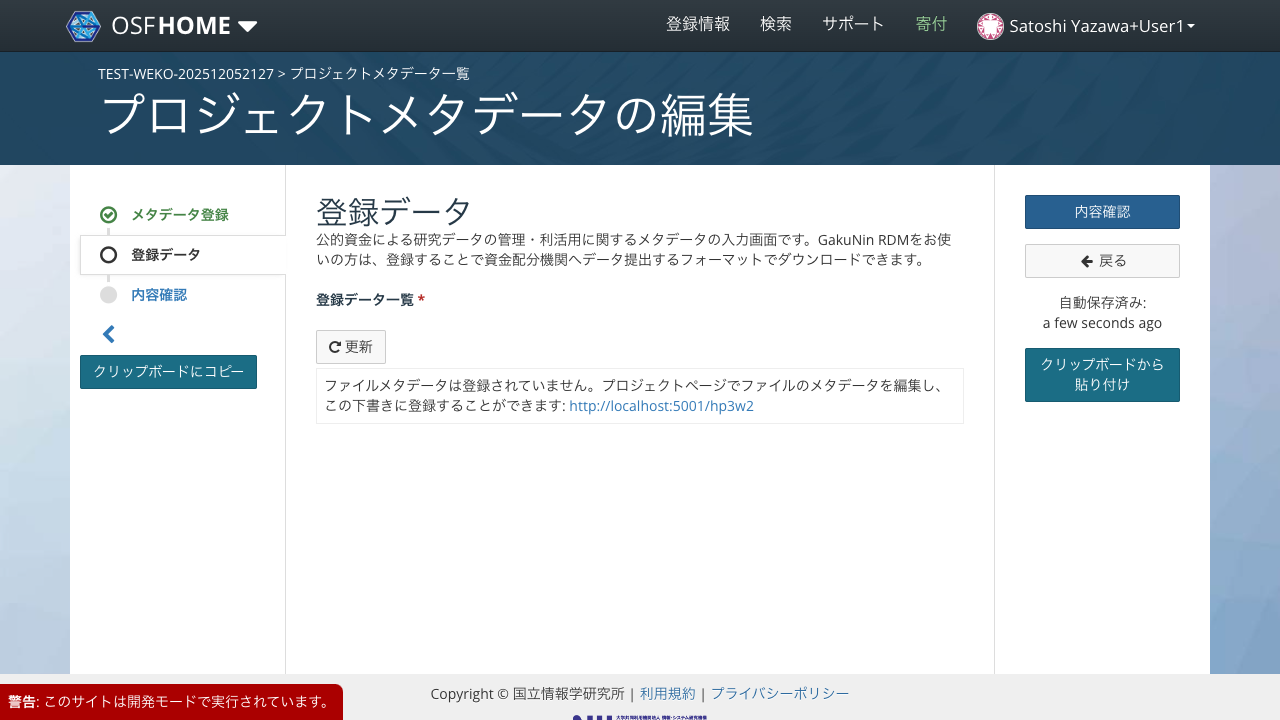

In [79]:
async def _step(page):
    await page.locator('//a[@data-test-goto-next-page]').click()
    await expect(page.locator('//a[contains(@data-test-link, "メタデータ登録")]//i[contains(@class, "fa-check")]')).to_be_visible(timeout=transition_timeout)
    await asyncio.sleep(10)

await run_pw(_step)

## プロジェクト名「TEST-WEKO-YYYYMMDDHHMM」をクリックする

プロジェクトダッシュボードが表示されること

Start epoch: 1765190434.1689339 seconds


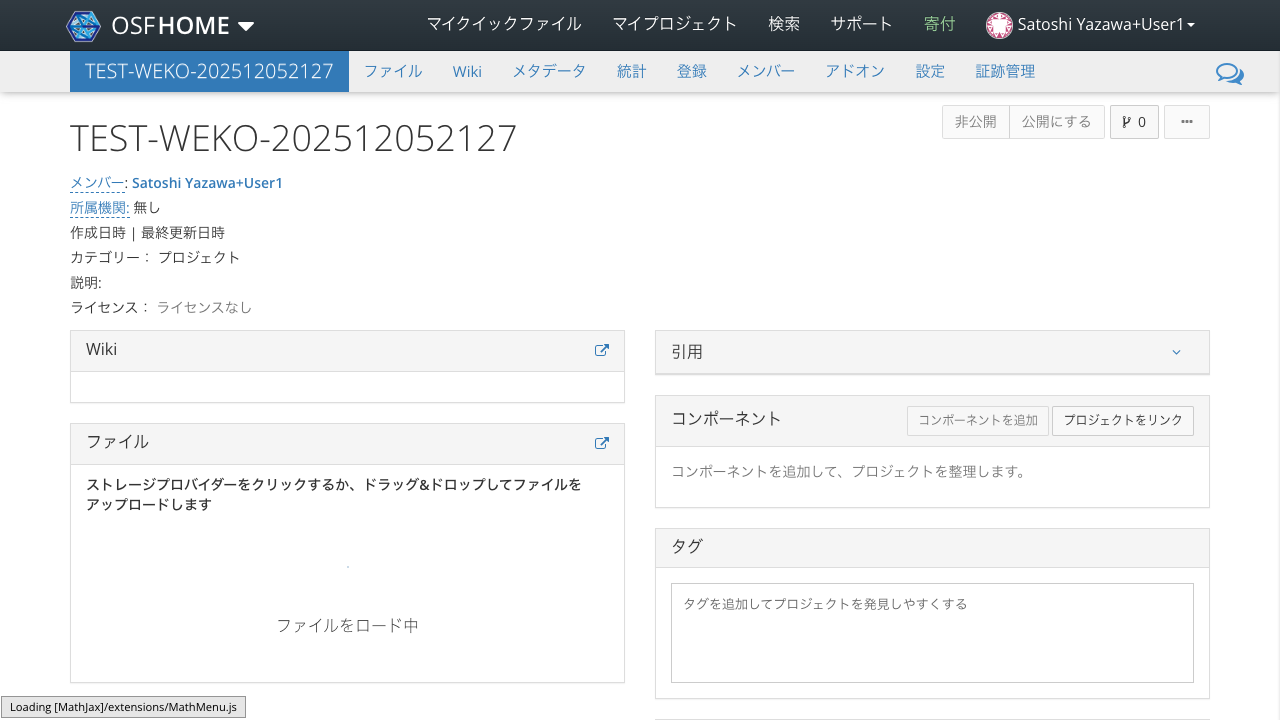

In [80]:
async def _step(page):
    await page.locator('//*[@data-analytics-name="Go to project"]').click()
    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「メタデータ」をクリックする

メタデータの一覧ページが表示されること

Start epoch: 1765190434.951492 seconds


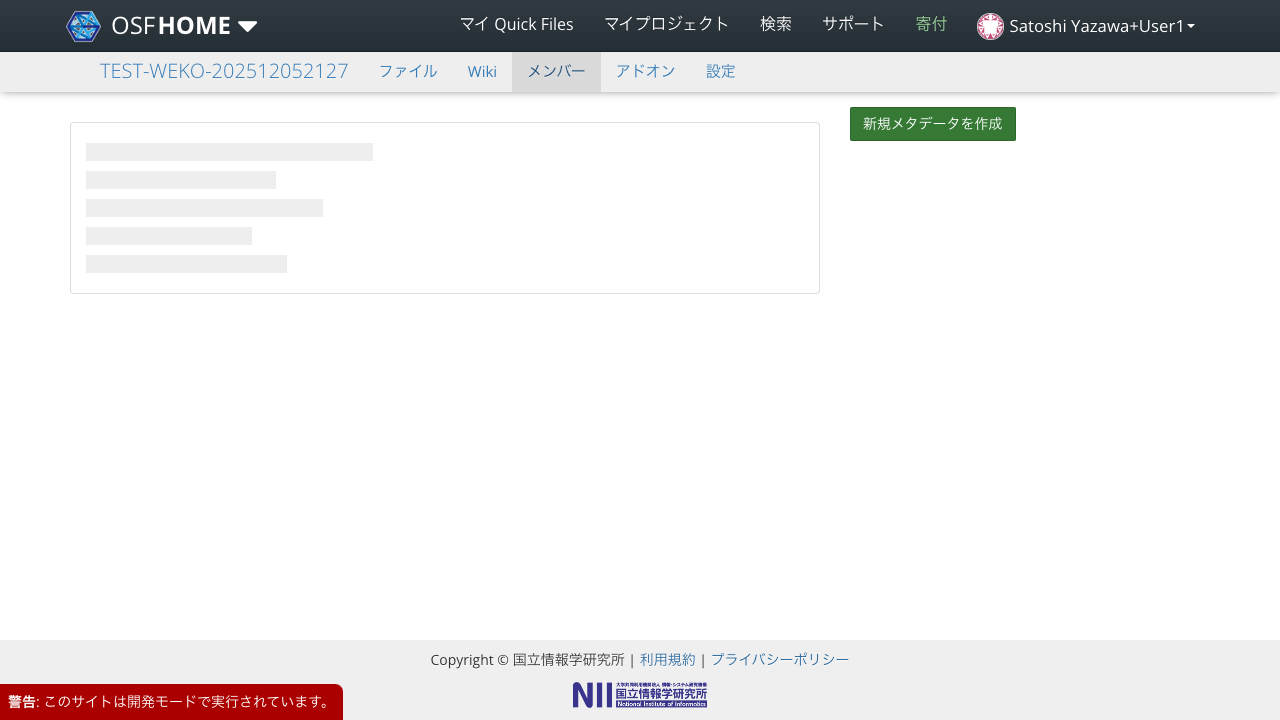

In [81]:
async def _step(page):
    await page.locator('//a[contains(text(), "メタデータ")]').click()
    await expect(page.locator('//*[@data-test-new-metadata-button]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「新規メタデータ」をクリックし「メタデータを作成」をクリックする

メタデータ編集ウィンドウが表示されること

Start epoch: 1765190440.3199182 seconds


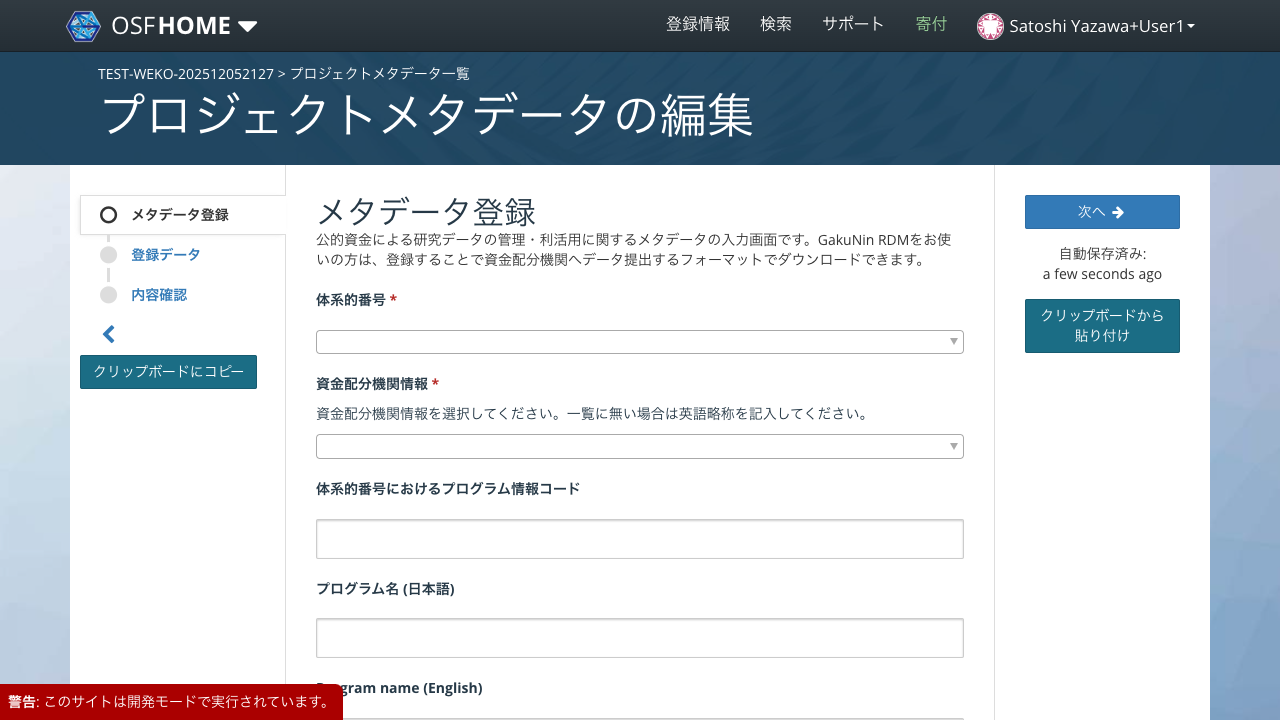

In [82]:
async def _step(page):
    await page.locator('//*[@data-test-new-metadata-button]').click()
    await expect(page.locator('//*[@data-test-new-report-modal-create-report-button]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//*[@data-test-new-report-modal-schema="公的資金による研究データのメタデータ登録"]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//*[@data-test-new-report-modal-create-report-button]').click()
    await expect(page.locator('//*[contains(text(), "資金配分機関情報")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 必須入力欄に正常系の値を入力する

正常系の値は以下の通り:
- 資金配分機関情報: 国立研究開発法人日本医療研究開発機構 | AMED
- 体系的番号: TEST123456
- プロジェクト名 (日本語): プロジェクトA必須
- プロジェクトの分野: 社会基盤 | 789

各フィールドに入力した値が表示されること

Start epoch: 1765190447.3847208 seconds


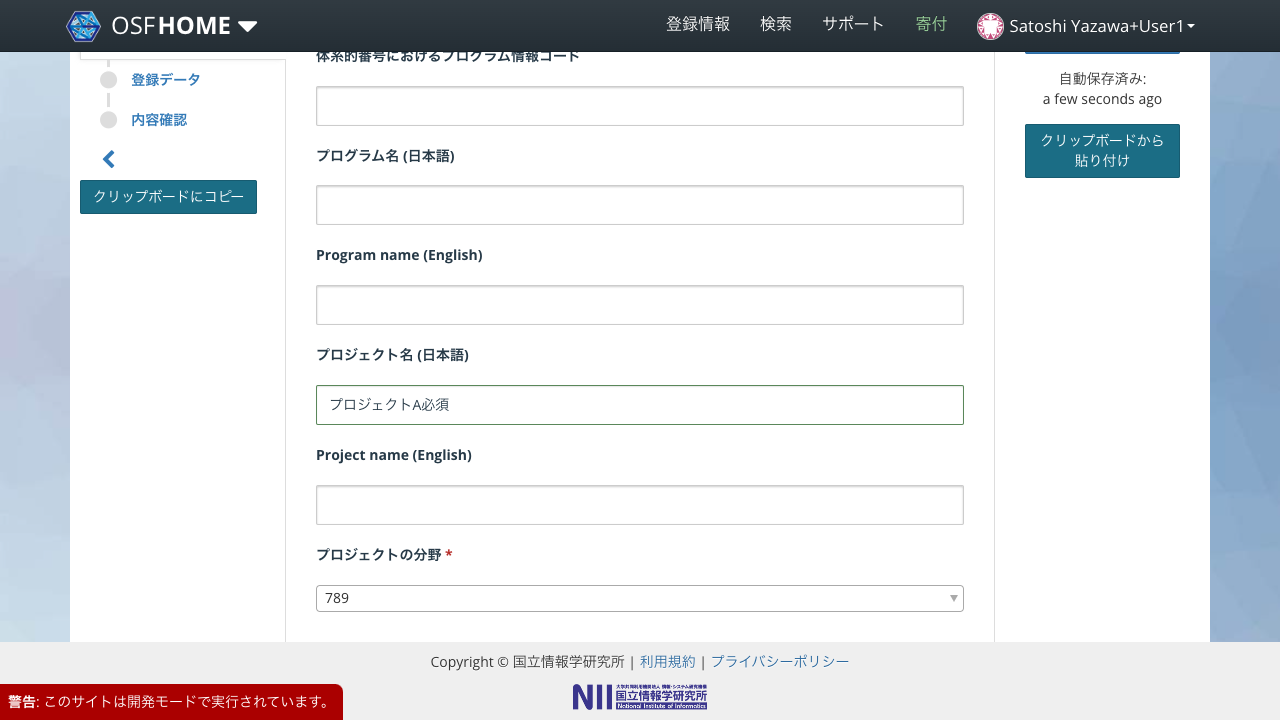

In [83]:
async def _step(page):
    form = ProjectMetadataForm(page)
    
    await form.fill("資金配分機関情報", "国立研究開発法人日本医療研究開発機構 | AMED")
    await form.fill_power_select_by_search("体系的番号", "TEST123456")
    await form.fill("プロジェクト名 (日本語)", "プロジェクトA必須")
    await form.fill("プロジェクトの分野", "社会基盤 | 789")
    
    # Verify values
    assert "AMED" in await form.get("資金配分機関情報")
    assert "TEST123456" in await form.get("体系的番号")
    assert await form.get("プロジェクト名 (日本語)") == "プロジェクトA必須"
    assert "789" in await form.get("プロジェクトの分野")

await run_pw(_step)

## 「次へ」をクリックする

左側ペイン「メタデータ登録」が緑色かつチェックマークが表示されること

Start epoch: 1765190447.7696068 seconds


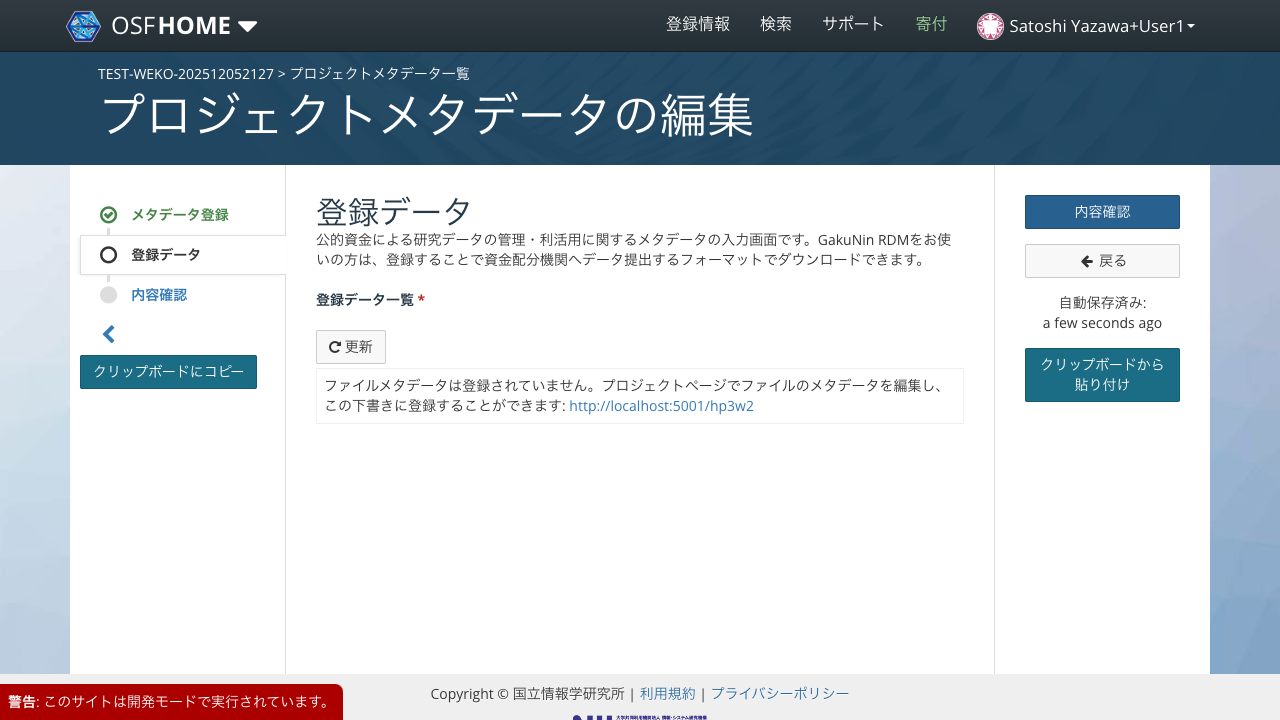

In [84]:
async def _step(page):
    await page.locator('//a[@data-test-goto-next-page]').click()
    await expect(page.locator('//a[contains(@data-test-link, "メタデータ登録")]//i[contains(@class, "fa-check")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクト名「TEST-WEKO-YYYYMMDDHHMM」をクリックする

プロジェクトダッシュボードが表示されること

Start epoch: 1765190447.9663 seconds


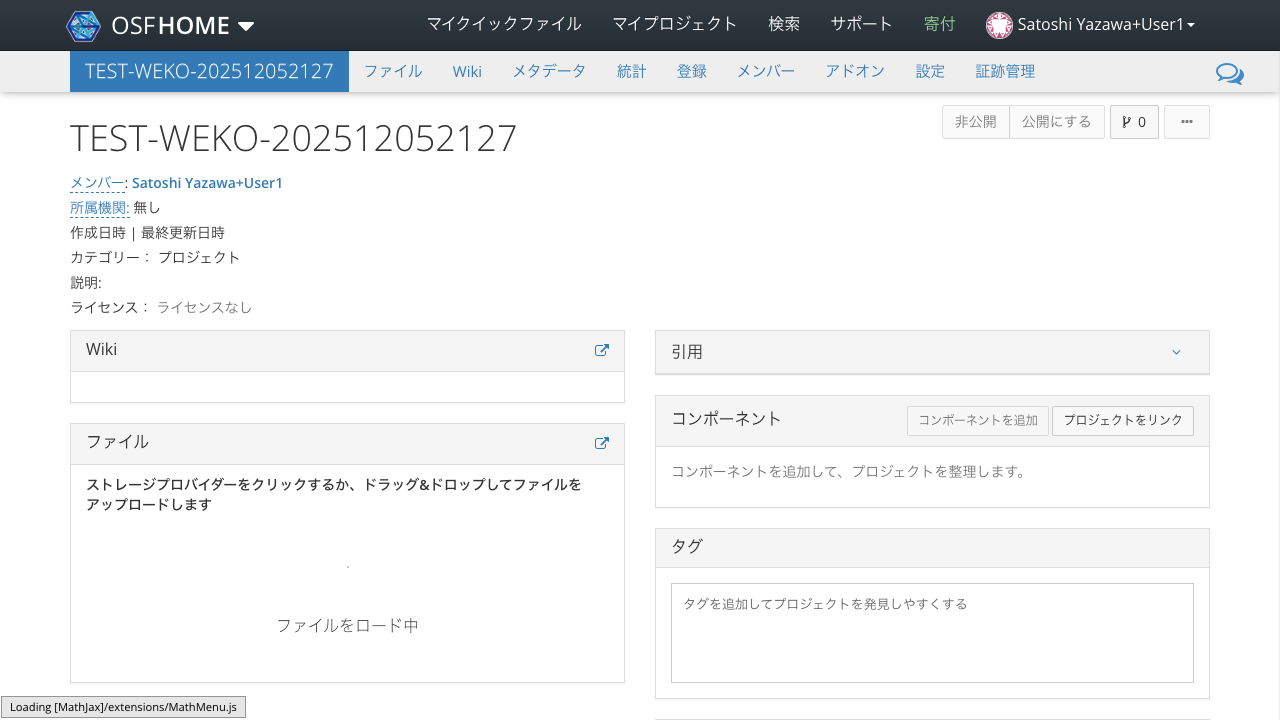

In [85]:
async def _step(page):
    await asyncio.sleep(10)
    await page.locator('//*[@data-analytics-name="Go to project"]').click()
    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## メタデータ一覧の「下書き」をクリックする

以下のメタデータが表示されること
- プロジェクトA必須
- プロジェクトA

Start epoch: 1765190458.860555 seconds


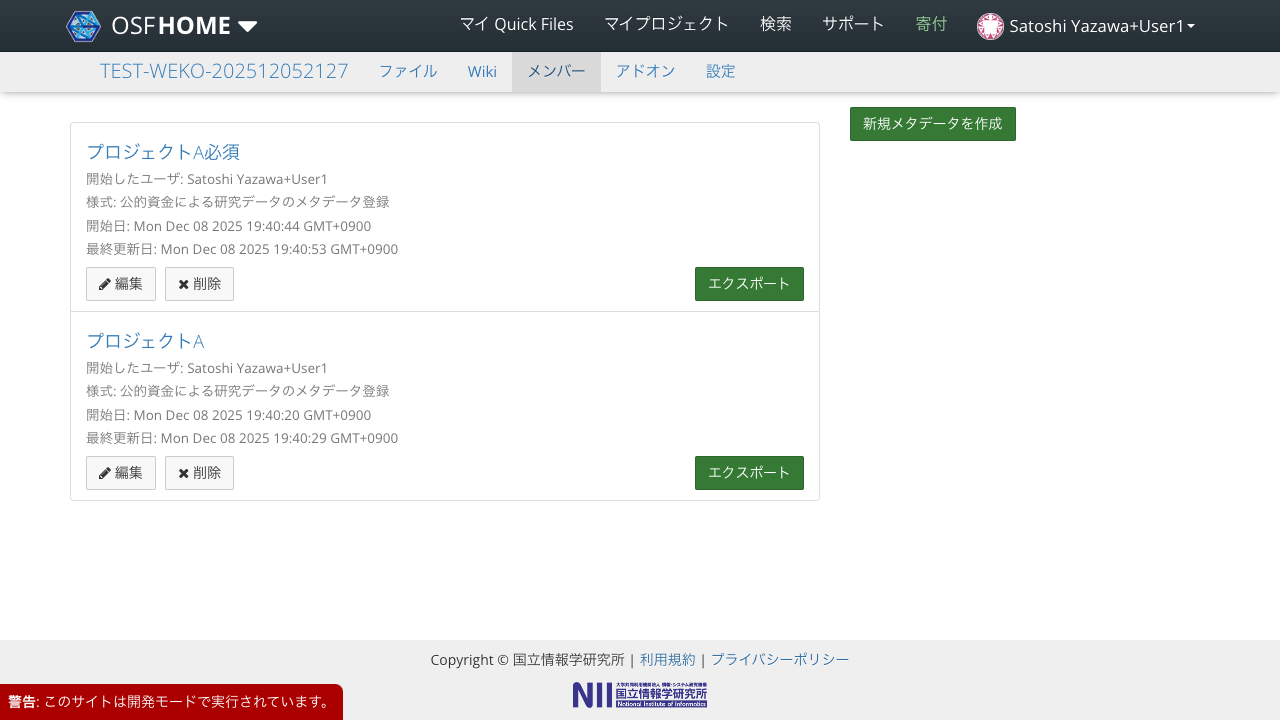

In [86]:
async def _step(page):
    await page.locator('//a[contains(text(), "メタデータ")]').click()
    await expect(page.locator('//*[@data-test-new-metadata-button]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//*[text() = "プロジェクトA必須"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//*[text() = "プロジェクトA"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクトダッシュボードの「JAIRO Cloud: (インデックス名)」をクリックする

「新規フォルダ作成」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1765190465.98688 seconds


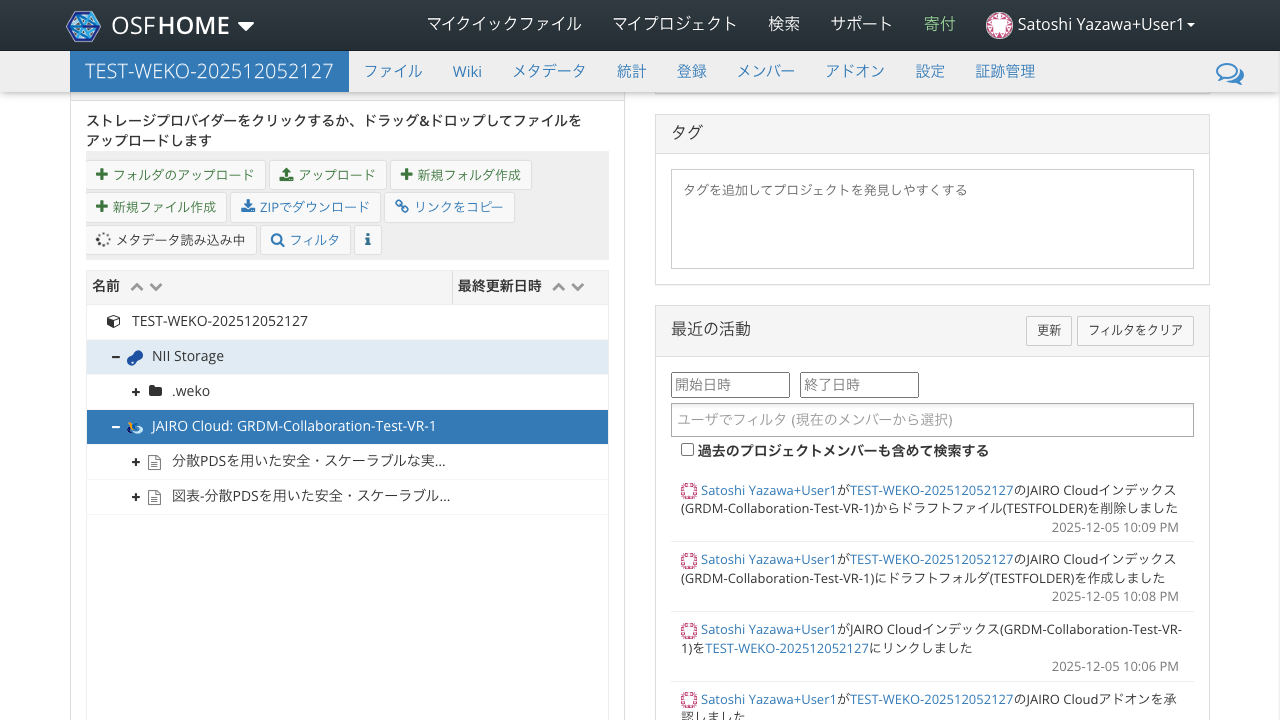

In [87]:
async def _step(page):
    await page.locator(f'//a[contains(@class, "project-title") and text() = "{project_name}"]').click()
    await expect(grdm.get_select_storage_title_locator(page, default_storage_label)).to_be_visible(timeout=transition_timeout)
    target_label = f'JAIRO Cloud: {weko_index_name}'
    await grdm.get_select_storage_title_locator(page, target_label).click()
    await expect(page.locator('//*[text() = "新規フォルダ作成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サンプル.pngファイルをアップロードする

テスト環境の「サンプル.png」をJAIRO Cloud配下にドラッグ＆ドロップする。

Start epoch: 1765190610.7398999 seconds


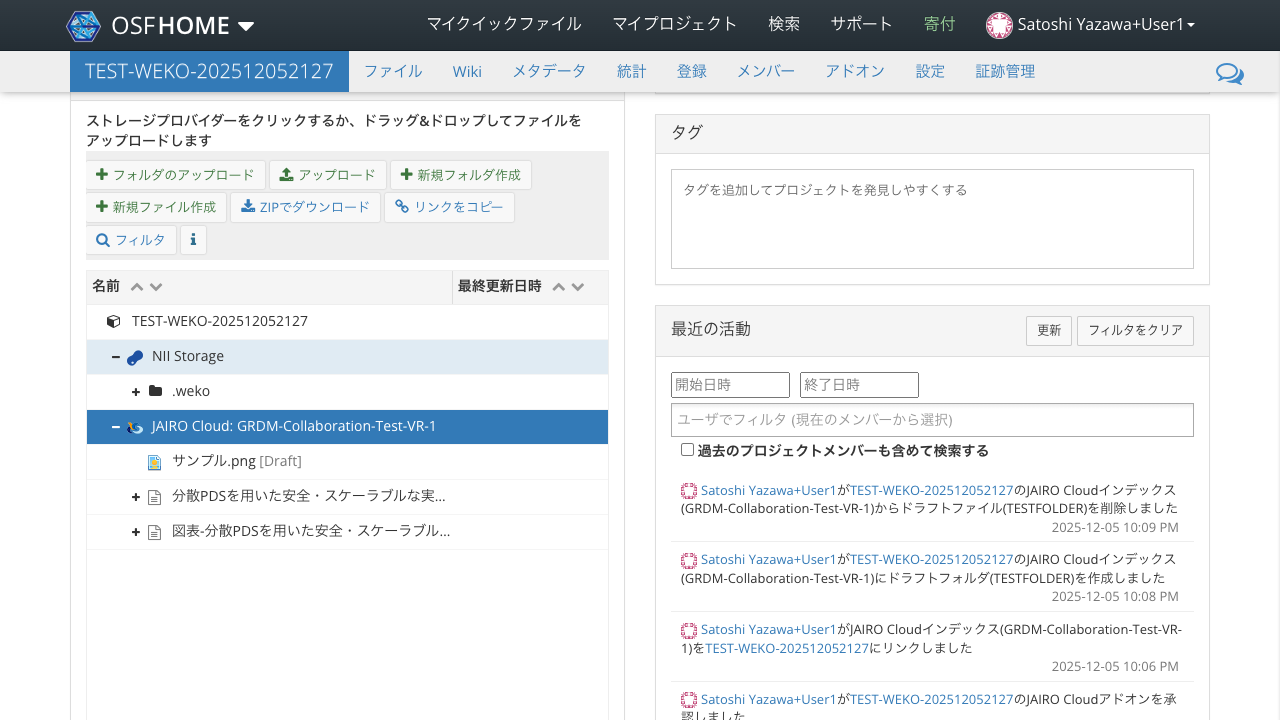

In [89]:
import os

sample_file_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'testdata', 'サンプル.png')

async def _step(page):
    target_label = f'JAIRO Cloud: {weko_index_name}'
    dropzone = grdm.get_select_storage_title_xpath(target_label)
    await grdm.drop_file(page, dropzone, sample_file_path)
    await expect(grdm.get_select_file_title_locator(page, 'サンプル.png')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「サンプル.png」のアイコンをクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1765191138.1964002 seconds


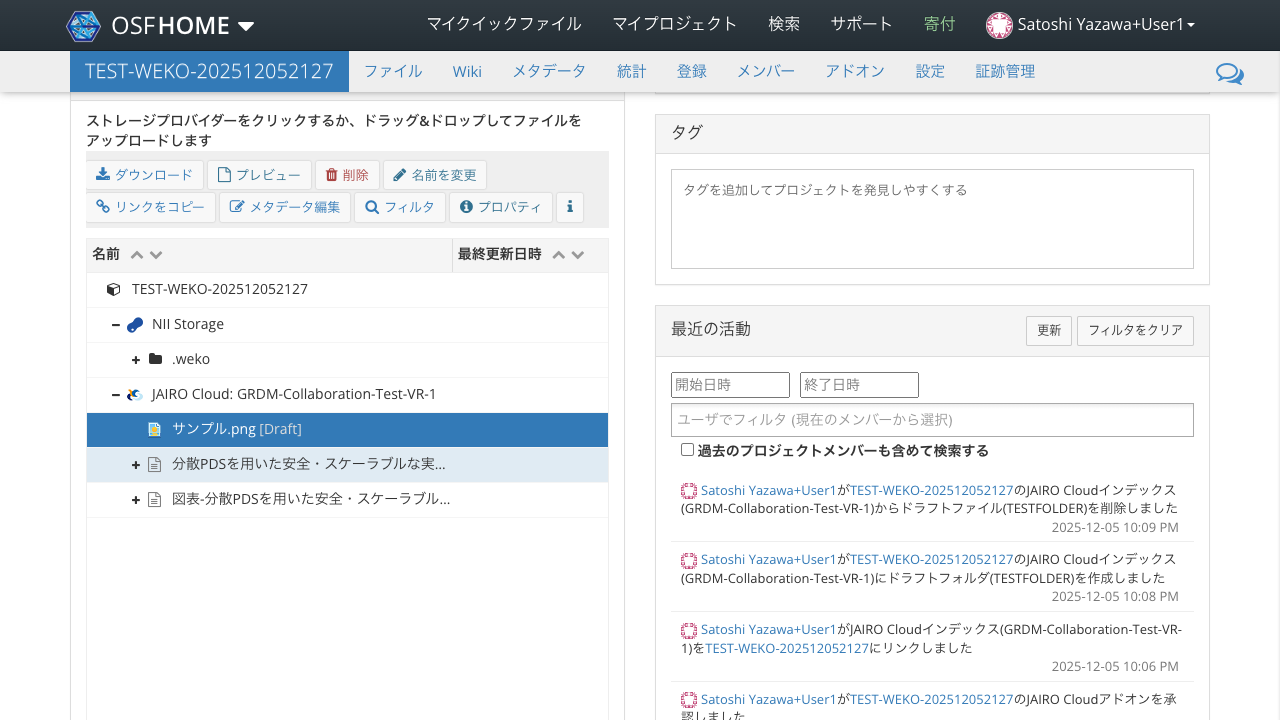

In [91]:
async def _step(page):
    await page.locator('//span[text() = "サンプル.png"]/../../..//div[contains(@class, "file-extension")]').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「メタデータ編集」をクリックする

「メタデータ編集」ダイアログが表示されること

Start epoch: 1765191223.132861 seconds


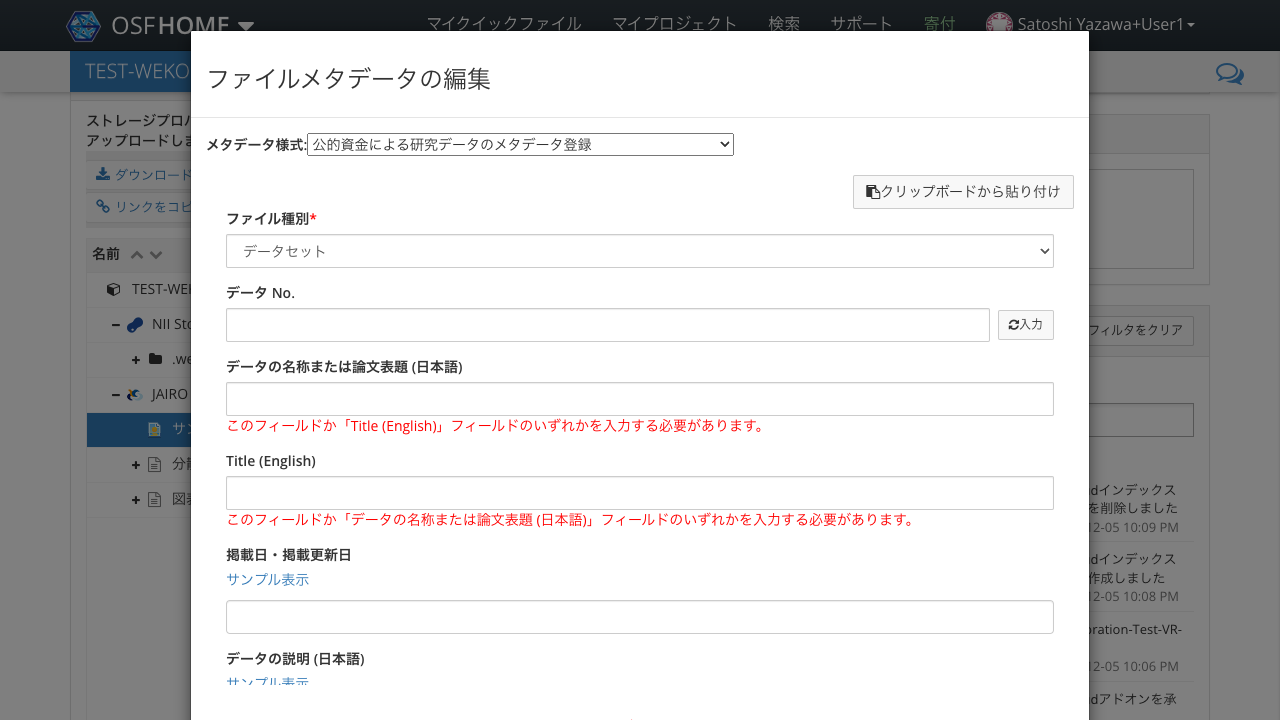

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    await expect(page.locator('//h3[contains(text(), "ファイルメタデータの編集")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「メタデータ様式」に「公的資金による研究データのメタデータ登録」を入力する

「データNo.」フィールドが表示されること

Start epoch: 1765191240.7131178 seconds


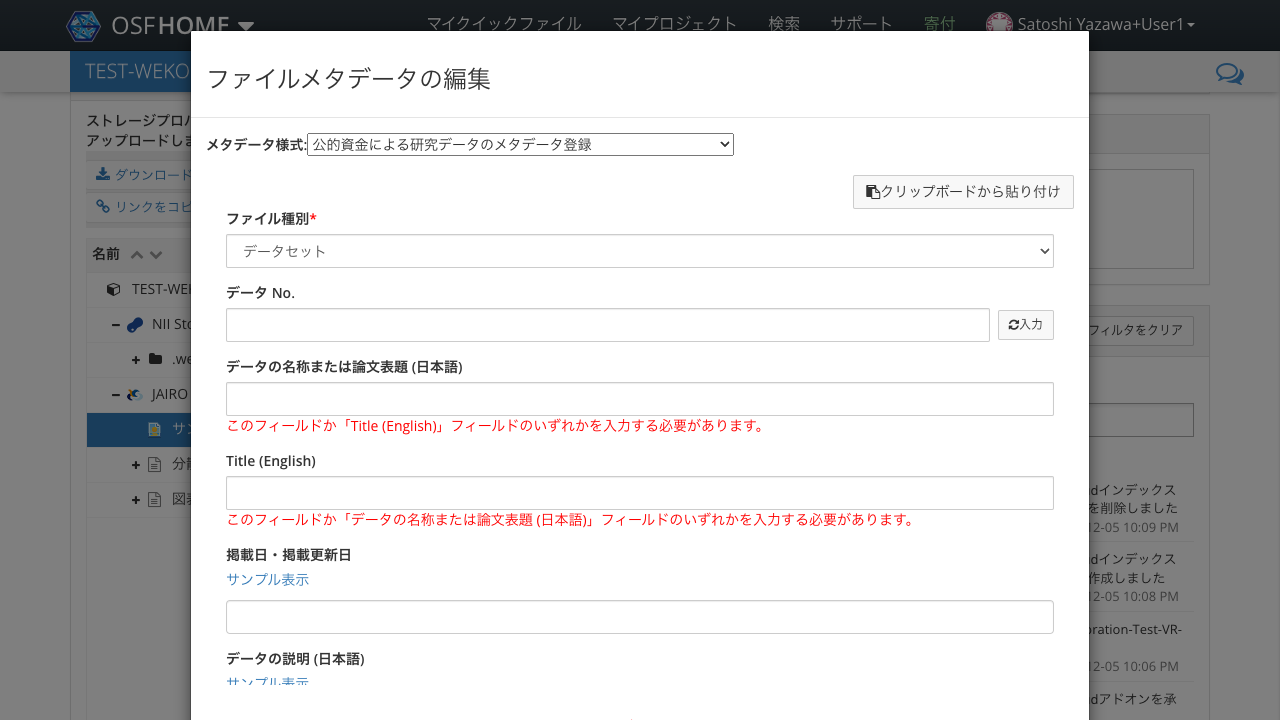

In [94]:
async def _step(page):
    schema_select = page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select')
    await schema_select.select_option(label="公的資金による研究データのメタデータ登録")
    await expect(page.locator('//label[contains(text(), "データ No.")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 全ての入力欄に正常系の値を入力する

正常系の値は以下の通り:
- データ No.: 123
- データの名称 (日本語): サンプルデータ
- Title (English): sample data
- 掲載日・掲載更新日: 2030-01-01
- データの説明 (日本語): データの説明
- Description (English): data description
- データの分野: ライフサイエンス
- データ種別: 集計データ
- 概略データ量: 1KB
- 管理対象データの利活用・提供方針 (有償/無償): 無償
- 管理対象データの利活用・提供方針 (ライセンス): CC0 1.0 Universal
- 管理対象データの利活用・提供方針 (引用方法等・日本語): 引用方法の説明
- Data utilization and provision policy (citation information, English): citation information
- アクセス権: 公開
- 公開予定日: 2030-01-01
- リポジトリ情報 (日本語): リポジトリの情報
- Repository information (English): repository information
- リポジトリURL・DOIリンク: https://example.com/example
- データ作成者: [{e-Rad: '123', 日本語: '情報データ太郎', English: 'Taro Data Joho'}, {e-Rad: '456', 日本語: 'あああ', English: 'aaa'}]
- データ管理機関 (日本語): データ管理機関
- Hosting institution (English): Hosting institution
- データ管理機関コード: code
- データ管理者の種類: 個人
- データ管理者の e-Rad 研究者番号: 123
- データ管理者 (日本語): 情報データ太郎
- Data manager (English): Taro Data Joho
- データ管理者の所属組織名 (日本語): データ管理者の所属組織名
- Contact organization of data manager (English): Contact organization of data manager
- データ管理者の所属機関の連絡先住所 (日本語): 愛知県 名古屋市
- Contact address of data manager (English): Aichi, Nagoya
- データ管理者の所属機関の連絡先電話番号: 123-456-789
- データ管理者の所属機関の連絡先メールアドレス: sample@example.com
- 備考 (日本語): 備考123
- Remarks (English): Remarks123
- メタデータのアクセス権: 公開

各フィールドに入力した値が表示されること

In [95]:
async def _step(page):
    form = FileMetadataForm(page)
    
    await form.fill("データ No.", "123")
    await form.fill("データの名称 (日本語)", "サンプルデータ")
    await form.fill("Title (English)", "sample data")
    await form.fill("掲載日・掲載更新日", "2030-01-01")
    await form.fill("データの説明 (日本語)", "データの説明")
    await form.fill("Description (English)", "data description")
    await form.fill("データの分野", "ライフサイエンス")
    await form.fill("データ種別", "集計データ")
    await form.fill("概略データ量", "1KB")
    await form.fill("管理対象データの利活用・提供方針 (有償/無償)", "無償")
    await form.fill("管理対象データの利活用・提供方針 (ライセンス)", "CC0 1.0 Universal")
    await form.fill("管理対象データの利活用・提供方針 (引用方法等・日本語)", "引用方法の説明")
    await form.fill("Data utilization and provision policy (citation information, English)", "citation information")
    await form.fill("アクセス権", "公開")
    await form.fill("公開予定日", "2030-01-01")
    await form.fill("リポジトリ情報 (日本語)", "リポジトリの情報")
    await form.fill("Repository information (English)", "repository information")
    await form.fill("リポジトリURL・DOIリンク", "https://example.com/example")
    
    # Table: データ作成者 - add first row
    await form.fill_table_cell("データ作成者", 0, 0, "123")
    await form.fill_table_cell("データ作成者", 0, 1, "情報データ太郎")
    await form.fill_table_cell("データ作成者", 0, 2, "Taro Data Joho")
    # Add second row
    await form.click_table_add_row("データ作成者")
    await form.fill_table_cell("データ作成者", 1, 0, "456")
    await form.fill_table_cell("データ作成者", 1, 1, "あああ")
    await form.fill_table_cell("データ作成者", 1, 2, "aaa")
    
    await form.scroll_to("データ管理機関 (日本語)")
    await form.fill("データ管理機関 (日本語)", "データ管理機関")
    await form.fill("Hosting institution (English)", "Hosting institution")
    await form.fill("データ管理機関コード", "code")
    await form.fill("データ管理者の種類", "個人")
    await form.fill("データ管理者の e-Rad 研究者番号", "123")
    await form.fill("データ管理者 (日本語)", "情報データ太郎")
    await form.fill("Data manager (English)", "Taro Data Joho")
    await form.fill("データ管理者の所属組織名 (日本語)", "データ管理者の所属組織名")
    await form.fill("Contact organization of data manager (English)", "Contact organization of data manager")
    await form.fill("データ管理者の所属機関の連絡先住所 (日本語)", "愛知県 名古屋市")
    await form.fill("Contact address of data manager (English)", "Aichi, Nagoya")
    await form.fill("データ管理者の所属機関の連絡先電話番号", "123-456-789")
    await form.fill("データ管理者の所属機関の連絡先メールアドレス", "sample@example.com")
    await form.fill("備考 (日本語)", "備考123")
    await form.fill("Remarks (English)", "Remarks123")
    await form.fill("メタデータのアクセス権", "公開")
    
    # Verify some key values
    await form.scroll_to("データ No.")
    assert await form.get("データ No.") == "123"
    assert await form.get("データの名称 (日本語)") == "サンプルデータ"

await run_pw(_step)

Start epoch: 1765191240.843387 seconds
Screenshot: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpoxftrs4z/last-screenshot.png


TimeoutError: Locator.clear: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("//label[contains(text(), \"データの名称 (日本語)\")]/../following-sibling::div//input")


## 「保存してJAIRO Cloudに登録」をクリックする

ファイルメタデータの編集ダイアログが非表示になり、ファイルの登録ダイアログが表示されること

In [ ]:
async def _step(page):
    await page.locator('//a[text()="保存してJAIRO Cloudに登録"]').click()
    await expect(page.locator('//h3[contains(text(), "ファイル") or contains(text(), "登録")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクトA」のチェックボックスをクリックする

チェックボックスがチェックされた状態になること

In [ ]:
async def _step(page):
    checkbox = page.locator('//div[@class="modal fade in"]//*[contains(text(), "プロジェクトA (")]/..//input[@type = "checkbox"]')
    await checkbox.click()
    await expect(checkbox).to_be_checked(timeout=transition_timeout)

await run_pw(_step)

## 「OK」をクリックする

ファイルビューが更新され、「JAIRO Cloud」配下に「サンプルデータ」アイテムが作成されること

In [ ]:
async def _step(page):
    await page.locator('//div[@class="modal fade in"]//a[text()="OK"]').click()
    await expect(page.locator('//*[contains(@class, "weko-row")]//*[text() = "サンプルデータ"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「JAIRO Cloud」配下の「サンプルデータ」アイテムをクリックする

新たにタブが開き、WEKO3の画面が表示されること

In [ ]:
import asyncio

async def _step(page):
    popup_future = page.context.wait_for_event('page')
    await page.locator('//*[contains(@class, "weko-row")]//*[text() = "サンプルデータ"]').click()
    popup = await popup_future
    await popup.wait_for_load_state()
    await expect(popup.locator('//a[contains(text(), "JSON")]')).to_be_visible(timeout=transition_timeout)
    return popup

weko_page = await run_pw(_step)

## WEKOで「Delete」をクリックし、アイテムを削除する

アイテムが削除されること

In [ ]:
async def _step(page):
    await page.locator('//a[@id = "btn_delete"]').click()
    await expect(page.locator('//*[contains(text(), "削除") or contains(text(), "delete")]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//button[text()="OK"]').click()
    await asyncio.sleep(2)

await _step(weko_page)
await weko_page.close()

## プロジェクトダッシュボードに戻り、「JAIRO Cloud」配下にファイルをアップロードする（必須項目のみ入力テスト）

ファイルがアップロードされること

In [ ]:
async def _step(page):
    await page.goto(project_url)
    await expect(grdm.get_select_storage_title_locator(page, default_storage_label)).to_be_visible(timeout=transition_timeout)
    target_label = f'JAIRO Cloud: {weko_index_name}'
    await grdm.get_select_storage_title_locator(page, target_label).click()
    await expect(page.locator('//*[text() = "新規フォルダ作成"]')).to_be_visible(timeout=transition_timeout)
    
    dropzone = grdm.get_select_storage_title_xpath(target_label)
    await grdm.drop_file(page, dropzone, sample_file_path)
    await expect(grdm.get_select_file_title_locator(page, 'サンプル.png')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## ファイルのメタデータ編集ダイアログを開き、必須項目のみ入力する

必須項目:
- データの名称 (日本語): サンプルデータ
- データの説明 (日本語): データの説明
- データの分野: ライフサイエンス
- データ種別: 集計データ
- 管理対象データの利活用・提供方針 (有償/無償): 無償
- 管理対象データの利活用・提供方針 (ライセンス): CC0 1.0 Universal
- 管理対象データの利活用・提供方針 (引用方法等・日本語): 引用方法の説明
- Data utilization and provision policy (citation information, English): citation information
- アクセス権: 公開
- データ管理機関 (日本語): データ管理機関
- データ管理者の種類: 個人
- データ管理者 (日本語): 情報データ太郎
- メタデータのアクセス権: 公開

In [ ]:
async def _step(page):
    await page.locator('//span[text() = "サンプル.png"]/../../..//div[contains(@class, "file-extension")]').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//*[text() = "メタデータ編集"]').click()
    await expect(page.locator('//h3[contains(text(), "メタデータ編集")]')).to_be_visible(timeout=transition_timeout)
    
    schema_select = page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select')
    await schema_select.select_option(label="公的資金による研究データのメタデータ登録")
    await expect(page.locator('//label[contains(text(), "データ No.")]')).to_be_visible(timeout=transition_timeout)
    
    form = FileMetadataForm(page)
    
    await form.fill("データの名称 (日本語)", "サンプルデータ")
    await form.fill("データの説明 (日本語)", "データの説明")
    await form.fill("データの分野", "ライフサイエンス")
    await form.fill("データ種別", "集計データ")
    await form.fill("管理対象データの利活用・提供方針 (有償/無償)", "無償")
    await form.fill("管理対象データの利活用・提供方針 (ライセンス)", "CC0 1.0 Universal")
    await form.fill("管理対象データの利活用・提供方針 (引用方法等・日本語)", "引用方法の説明")
    await form.fill("Data utilization and provision policy (citation information, English)", "citation information")
    await form.fill("アクセス権", "公開")
    await form.scroll_to("データ管理機関 (日本語)")
    await form.fill("データ管理機関 (日本語)", "データ管理機関")
    await form.fill("データ管理者の種類", "個人")
    await form.fill("データ管理者 (日本語)", "情報データ太郎")
    await form.fill("メタデータのアクセス権", "公開")

await run_pw(_step)

## 「保存してJAIRO Cloudに登録」をクリックし、「プロジェクトA必須」を選択して「OK」をクリックする

「JAIRO Cloud」配下に「サンプルデータ」アイテムが作成されること

In [ ]:
async def _step(page):
    await page.locator('//a[text()="保存してJAIRO Cloudに登録"]').click()
    await expect(page.locator('//h3[contains(text(), "ファイル") or contains(text(), "登録")]')).to_be_visible(timeout=transition_timeout)
    
    checkbox = page.locator('//div[@class="modal fade in"]//*[contains(text(), "プロジェクトA必須 (")]/..//input[@type = "checkbox"]')
    await checkbox.click()
    await expect(checkbox).to_be_checked(timeout=transition_timeout)
    
    await page.locator('//div[@class="modal fade in"]//a[text()="OK"]').click()
    await expect(page.locator('//*[contains(@class, "weko-row")]//*[text() = "サンプルデータ"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「JAIRO Cloud」配下の「サンプルデータ」アイテムをクリックし、WEKOで削除する

アイテムが削除されること

In [ ]:
async def _step(page):
    popup_future = page.context.wait_for_event('page')
    await page.locator('//*[contains(@class, "weko-row")]//*[text() = "サンプルデータ"]').click()
    popup = await popup_future
    await popup.wait_for_load_state()
    await expect(popup.locator('//a[@id = "btn_delete"]')).to_be_visible(timeout=transition_timeout)
    await popup.locator('//a[@id = "btn_delete"]').click()
    await expect(popup.locator('//*[contains(text(), "削除") or contains(text(), "delete")]')).to_be_visible(timeout=transition_timeout)
    await popup.locator('//button[text()="OK"]').click()
    await asyncio.sleep(2)
    await popup.close()

await run_pw(_step)

## 「NII Storage」(または機関ストレージ)をクリックし、フォルダを作成する

「TESTMETADATA」フォルダが作成されること

In [ ]:
async def _step(page):
    await page.goto(project_url)
    await expect(grdm.get_select_storage_title_locator(page, default_storage_label)).to_be_visible(timeout=transition_timeout)
    await grdm.get_select_storage_title_locator(page, default_storage_label).click()
    await expect(page.locator('//*[text() = "新規フォルダ作成"]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//*[text() = "新規フォルダ作成"]').click()
    await expect(page.locator('//input[@id = "createFolderInput"]')).to_be_visible(timeout=transition_timeout)
    folder_input = page.locator('//input[@id = "createFolderInput"]')
    await folder_input.fill('TESTMETADATA')
    await folder_input.press('Enter')
    await expect(grdm.get_select_folder_title_locator(page, 'TESTMETADATA')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TESTMETADATA」フォルダのメタデータを編集する

メタデータが設定されること

In [ ]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMETADATA').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//*[text() = "メタデータ編集"]').click()
    await expect(page.locator('//h3[contains(text(), "メタデータ編集")]')).to_be_visible(timeout=transition_timeout)
    
    schema_select = page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select')
    await schema_select.select_option(label="公的資金による研究データのメタデータ登録")
    await expect(page.locator('//label[contains(text(), "データ No.")]')).to_be_visible(timeout=transition_timeout)
    
    form = FileMetadataForm(page)
    
    await form.fill("データの名称 (日本語)", "サンプルデータ")
    await form.fill("データの説明 (日本語)", "データの説明")
    await form.fill("データの分野", "ライフサイエンス")
    await form.fill("データ種別", "集計データ")
    await form.fill("管理対象データの利活用・提供方針 (有償/無償)", "無償")
    await form.fill("管理対象データの利活用・提供方針 (ライセンス)", "CC0 1.0 Universal")
    await form.fill("管理対象データの利活用・提供方針 (引用方法等・日本語)", "引用方法の説明")
    await form.fill("Data utilization and provision policy (citation information, English)", "citation information")
    await form.fill("アクセス権", "公開")
    await form.scroll_to("データ管理機関 (日本語)")
    await form.fill("データ管理機関 (日本語)", "データ管理機関")
    await form.fill("データ管理者の種類", "個人")
    await form.fill("データ管理者 (日本語)", "情報データ太郎")
    await form.fill("メタデータのアクセス権", "公開")
    
    await page.locator('//button[contains(text(), "保存")]').click()
    await expect(page.locator('//h3[contains(text(), "メタデータ編集")]')).to_be_hidden(timeout=transition_timeout)

await run_pw(_step)

## 「TESTMETADATA」を「JAIRO Cloud」にドラッグ＆ドロップする

フォルダがコピーされること

In [ ]:
async def _step(page):
    target_label = f'JAIRO Cloud: {weko_index_name}'
    source = grdm.get_select_folder_draggable_locator(page, 'TESTMETADATA')
    dest = grdm.get_select_folder_droppable_locator(page, target_label)
    await grdm.drag_and_drop(page, source, dest)
    
    # Wait for copy completion or pending state
    await asyncio.sleep(3)
    
    # Check if registration dialog appears
    cancel_button = page.locator('//button[text() = "キャンセル"]')
    if await cancel_button.count() > 0:
        await cancel_button.click()

await run_pw(_step)

## JAIRO Cloud配下でフォルダを確認し、「登録」をクリックする

ファイルの登録ダイアログが表示されること

In [ ]:
async def _step(page):
    target_label = f'JAIRO Cloud: {weko_index_name}'
    await grdm.get_select_storage_title_locator(page, target_label).click()
    await expect(page.locator('//*[text() = "新規フォルダ作成"]')).to_be_visible(timeout=transition_timeout)
    
    # Wait for TESTMETADATA to appear
    await expect(grdm.get_select_folder_title_locator(page, 'TESTMETADATA')).to_be_visible(timeout=transition_timeout)
    
    await grdm.get_select_folder_title_locator(page, 'TESTMETADATA').click()
    await expect(page.locator('//*[text() = "登録"]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//*[text() = "登録"]').click()
    await expect(page.locator('//h3[contains(text(), "ファイル") or contains(text(), "登録")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクトA必須」のチェックボックスをクリックし、「OK」をクリックする

「JAIRO Cloud」配下に「サンプルデータ」アイテムが作成されること

In [ ]:
async def _step(page):
    checkbox = page.locator('//div[@class="modal fade in"]//*[contains(text(), "プロジェクトA必須")]/..//input[@type="checkbox"]')
    await checkbox.click()
    await expect(checkbox).to_be_checked(timeout=transition_timeout)
    
    await page.locator('//div[@class="modal fade in"]//a[text()="OK"]').click()
    await expect(page.locator('//*[contains(@class, "weko-row")]//*[text() = "サンプルデータ"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「JAIRO Cloud」配下の「サンプルデータ」アイテムをクリックし、WEKOで削除する

アイテムが削除されること

In [ ]:
async def _step(page):
    popup_future = page.context.wait_for_event('page')
    await page.locator('//*[contains(@class, "weko-row")]//*[text() = "サンプルデータ"]').click()
    popup = await popup_future
    await popup.wait_for_load_state()
    await expect(popup.locator('//a[@id = "btn_delete"]')).to_be_visible(timeout=transition_timeout)
    await popup.locator('//a[@id = "btn_delete"]').click()
    await expect(popup.locator('//*[contains(text(), "削除") or contains(text(), "delete")]')).to_be_visible(timeout=transition_timeout)
    await popup.locator('//button[text()="OK"]').click()
    await asyncio.sleep(2)
    await popup.close()

await run_pw(_step)

後始末

In [ ]:
await finish_pw_context(screenshot=False, last_path=default_result_path)

In [ ]:
!rm -fr {work_dir}